# Welcome to the Exoplanet Hackathon

## The Scientific Context

When a planet passes in front of its host star, it blocks a small fraction of the starlight reaching us, causing a measurable dip in the observed brightness. This is a planetary transit, and the brightness record over time is called a lightcurve. The depth of the dip tells us how large the planet is relative to its star.

![title](img/exosketch1.png)

When we observe the same transit at multiple wavelengths simultaneously, the depth of the dip varies. At wavelengths where atmospheric molecules absorb light, the planet appears slightly larger — its atmosphere is opaque at those frequencies. This wavelength-dependent signal is the transmission spectrum, and it encodes the chemical composition of the atmosphere directly.

![title](img/exosketch2.png)


The JWST observation of WASP-96 b below is a real example: the characteristic dips correspond to water vapour absorption at known wavelengths. This is the kind of signal your model will learn to interpret — though at the scale and wavelength coverage of Ariel rather than JWST.


![title](img/Exoplanet_WASP-96_b.png)

The Ariel Space Mission, launching in 2031, is designed to conduct the first large, systematic survey of exoplanet atmospheres — targeting over 1,000 planets with a homogeneous observing strategy. Where current facilities have yielded atmospheric constraints for roughly 100 planets, Ariel will deliver population-scale data. The dataset you are working with today consists of simulated Ariel observations, generated using a physically realistic forward model of the mission's expected performance.


![title](img/ariel_lowres.jpg)

---

## Why Atmospheric Characterisation Matters


Retrieving the chemical composition and thermal structure of an exoplanet atmosphere is a window into some of the most profound open questions in planetary science — how planets form and migrate, how their atmospheres evolve under stellar irradiation, and whether any harbour the molecular signatures of life.

Answering these questions rigorously requires not just predictions, but credible uncertainties. Conventional retrieval methods such as Nested Sampling and MCMC provide both, but at significant computational cost — typically hours per planet. At the population scale Ariel is designed to operate, this is no longer tractable.

Your task is to build a machine learning model that maps directly from an observed spectrum to atmospheric parameters and their uncertainties, replacing the iterative simulation loop shown below with a single fast inference step.

![Atmospheric retrieval schematic](img/02_retrieval.png)

---

## Today's Challenge

Given simulated Ariel observations of a population of exoplanets, your task is to build a model — or a suite of models — that retrieves the atmospheric properties of each planet and provides a quantified uncertainty for each prediction.

Concretely, for each planet in the dataset you are asked to predict:

| Target | Description |
|---|---|
| 5 molecular abundances | Volume mixing ratios of key chemical species (e.g. H2O, CO2, CH4, CO, NH3) |
| Atmospheric temperature | A representative temperature of the atmospheric layer probed by Ariel |
| Uncertainties | A well-calibrated estimate of confidence for each predicted quantity |

Ground truth is available for all targets, which means your model's performance — including the quality of its uncertainty estimates — can be evaluated directly and meaningfully.

---

## What This Notebook Covers

This starter notebook provides a structured on-ramp to the problem:

1. **Dataset walkthrough** — the structure of the inputs (spectra) and outputs (atmospheric parameters), and how they relate to one another
2. **Baseline model** — a working end-to-end solution that you can run, evaluate, and build upon
3. **Directions for exploration** — suggestions for where to go next

The aim is to ensure every team has something functional and well-understood before deeper exploration begins.

---




In [1]:
import numpy as np 
import pandas as pd
import h5py
import sklearn
import os
from utils import *
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor
from sklearn.model_selection import KFold, train_test_split
from IPython.display import Image
from IPython.core.display import HTML 

# Data Loading

All training data is contained within the `Hackathon_training` directory and consists of three files:

- **`Training_SpectralData.hdf5`** — the primary inputs: simulated Ariel transmission spectra for each planet in the training set.
- **`Training_targets.csv`** — the ground-truth atmospheric parameters (molecular abundances and temperature) that your model is trained to predict.
- **`Training_supplementary_data.csv`** — additional physical properties of each planetary system, such as stellar and planetary parameters, which may be used to augment your model inputs.

Detailed explanation below:

In [2]:
data_dir = 'Hackathon_training'
supp_data_path = os.path.join(data_dir, 'Training_supplementary_data.csv')
spectral_data_path = os.path.join(data_dir, 'Training_SpectralData.hdf5')
target_data_path = os.path.join(data_dir, 'Training_targets.csv')


## Handling Spectral Data

The spectral data is stored in `.hdf5` format, which we convert to matrix form for easier manipulation. Each observation entry (labelled `Planet_XXX`) contains four arrays:

| Array | Description |
|---|---|
| `wavelength` | The central wavelength of each spectral channel, defining the instrument's wavelength coverage |
| `spectrum` | The observed transit depth as a function of wavelength — the core signal you will be modelling |
| `noise` | The per-channel uncertainty on the observed spectrum, which varies between planets |
| `width` | The wavelength width of each spectral channel |

Note that the wavelength grid and channel widths are identical across all observations — Ariel observes every target with the same instrument configuration. What varies from planet to planet is the noise, reflecting differences in stellar brightness, planetary signal strength, and the number of transits observed.

In [3]:
spectrum_stack, noise_stack, wl_grid, width = load_spectral_data(spectral_data_path)


## Handling Target and Supplementary Data

Both files are stored in `.csv` format and can be loaded directly with standard tools such as `pandas`.

**Training targets** (`training_targets.csv`) contain the ground-truth atmospheric parameters — molecular abundances and temperature — for the training set. These are the quantities your model is trained to predict. No equivalent file exists for the test set; recovering those values from the spectral data is precisely the task.

**Supplementary data** contains additional physical properties of each planet — such as stellar and planetary parameters — that provide broader context about each system. These features are not strictly required to make predictions, but they carry information about the physical characteristics of the planet that may help improve model performance. In this notebook we do not make use of them, but they represent a natural avenue for exploration during the hackathon.


In [4]:
y_true = pd.read_csv(target_data_path, index_col=0)
x_supp = pd.read_csv(supp_data_path,index_col=0)

In [5]:
y_true.shape, x_supp.shape

((69404, 7), (69404, 10))

# Making Sense of the Data

Before building any model, it is worth spending time understanding the structure of the dataset. This section walks through the key statistical properties of both the inputs — the observed spectra — and the targets — the atmospheric parameters you are asked to predict.

This is not merely a preliminary step. The choices you make later, in terms of preprocessing, feature engineering, and model architecture, should be grounded in what the data actually looks like. Patterns you identify here will directly inform how you approach the modelling problem.


The population overview (figure 1) reveals the diversity of the dataset at a glance. Individual spectra span nearly two orders of magnitude in transit depth, reflecting the wide range of planetary sizes in the sample. The noise panel shows that measurement uncertainty is low and consistent at shorter wavelengths but rises sharply beyond ~2 μm, where Ariel's detectors become less sensitive — not all wavelength channels carry equal information.

Zooming into a single planet (Figure 2), Planet 7 is a high-SNR target (mean SNR 110, peaking near 0.95 μm) whose spectrum shows clear molecular absorption features. The tight uncertainty bands confirm these features are statistically significant. The SNR panel shows signal quality dropping in the infrared, consistent with the population-level noise pattern above.


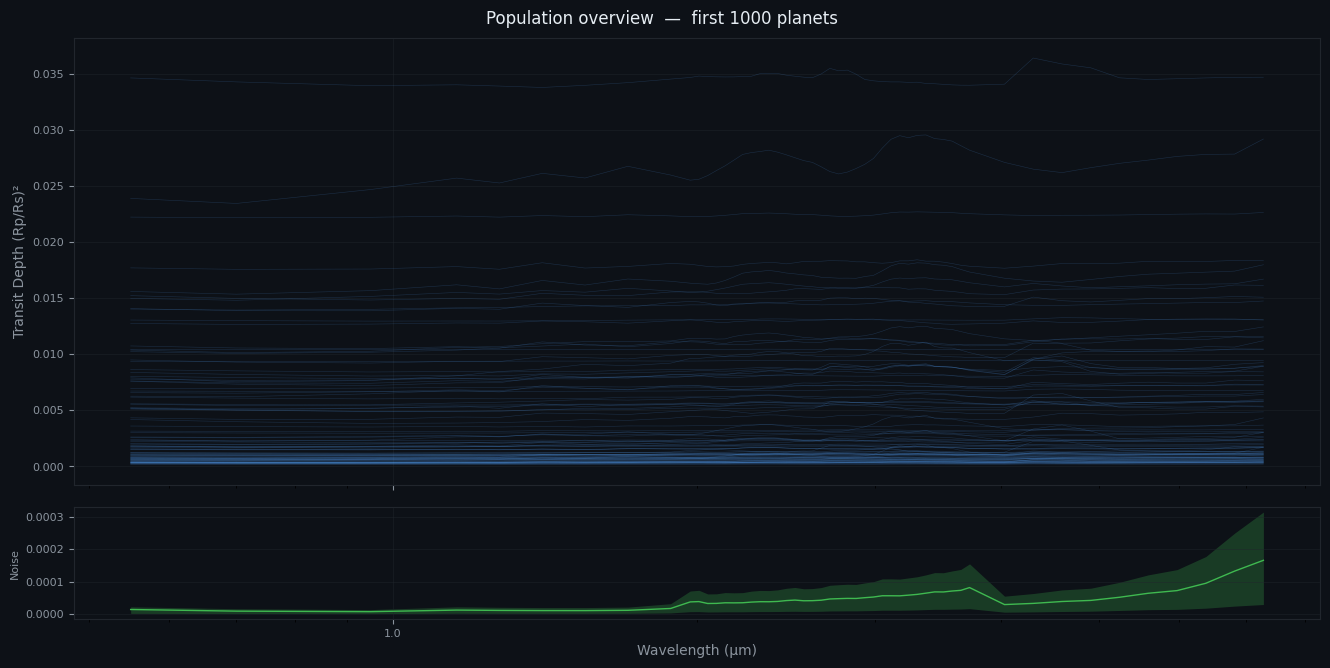

In [6]:
plot_population_overview(spectrum_stack, noise_stack, wl_grid, n_planets=1000)

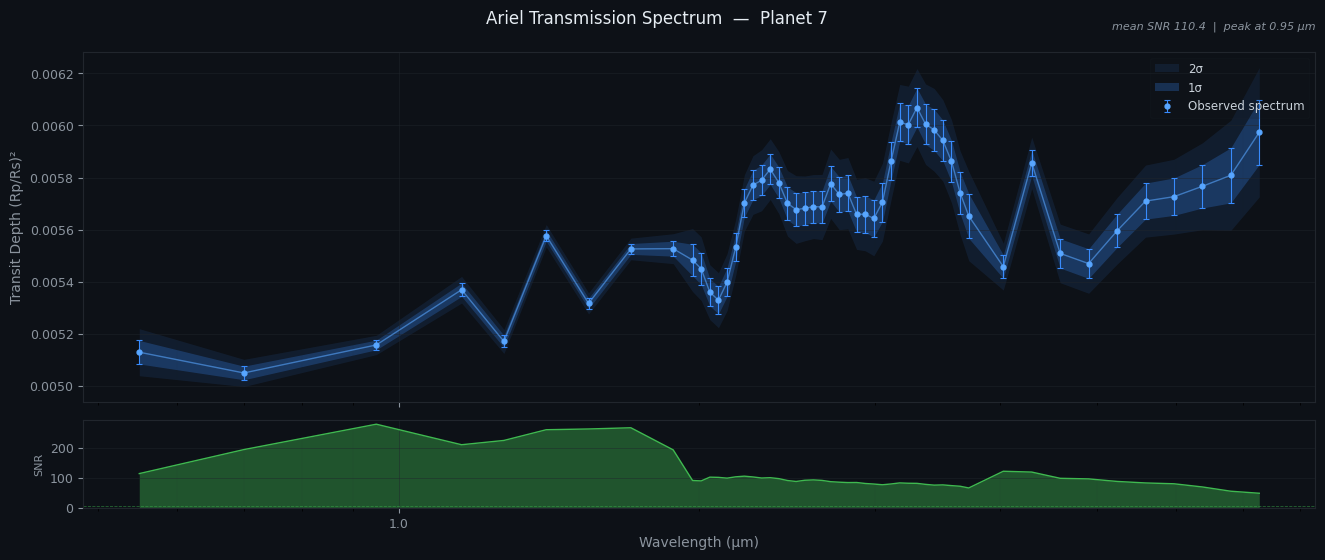

In [7]:
plot_spectrum(7, spectrum_stack, noise_stack, wl_grid, y_true=None)

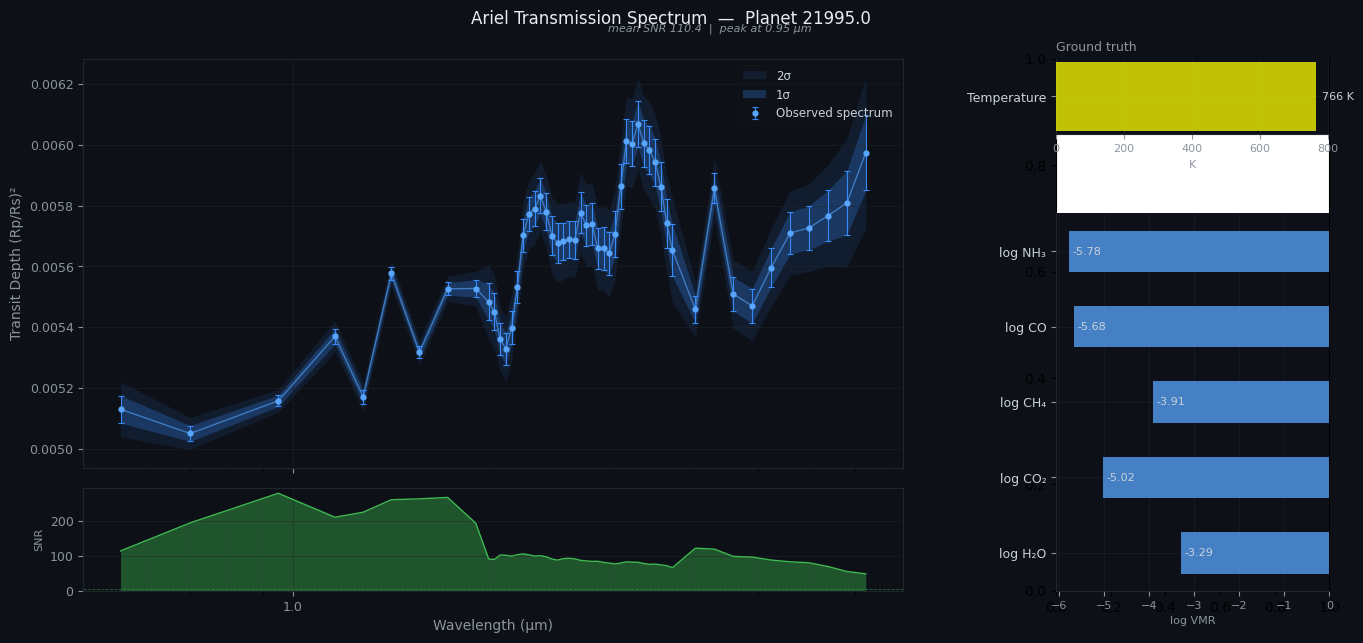

In [8]:
plot_spectrum(7, spectrum_stack, noise_stack, wl_grid, y_true=y_true)

In [9]:
# What about the supplementary data? (yours to figure out)
# What about the targets? (Yours to figure out)

# Baseline Solution

We use scikit-learn to construct our first model. A central concern in any machine learning pipeline is whether a model generalises beyond the data it was trained on — a model that simply memorises its training set is of little scientific value. The standard approach to measuring this is the **train-test split**: hold out a portion of labelled data, train on the remainder, and evaluate on the held-out set.

Here we use a more rigorous variant: **k-fold cross-validation**. The training set is partitioned into *k* equal folds; the model is trained on *k-1* folds and evaluated on the remaining one. This is repeated *k* times so that every sample serves as a validation point exactly once. The result is a more reliable estimate of generalisation performance, along with a measure of how consistent that performance is across different data splits.

We take this one step further. Rather than discarding the *k* models after evaluation, we retain all of them as an **ensemble**. At inference time, each model in the ensemble produces an independent prediction on the test set. The mean of those predictions is our point estimate; the standard deviation is our uncertainty estimate. 

![title](img/03_ensemble_schematic.png)



In [10]:

TARGET_COLS = ['planet_temp', 'log_H2O', 'log_CO2', 'log_CH4', 'log_CO', 'log_NH3']
N_SPLITS    = 5

X = spectrum_stack
y = y_true[TARGET_COLS].values

# --- hold out a test set before any model sees the data ------------------
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print(f"Development set : {X_dev.shape[0]:>6} samples")
print(f"Test set        : {X_test.shape[0]:>6} samples\n")

# --- cross-validation on the development set only ------------------------
kf     = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
models = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_dev)):
    X_train, X_val = X_dev[train_idx], X_dev[val_idx]
    y_train, y_val = y_dev[train_idx], y_dev[val_idx]

    model = ExtraTreesRegressor(n_estimators=10, n_jobs=-1, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    mae    = np.mean(np.abs(y_val - y_pred))
    rmse   = np.sqrt(np.mean(np.square(y_val - y_pred)))
    r2     = model.score(X_val, y_val)
    print(f"Fold {fold + 1} / {N_SPLITS}  |  MAE = {mae:.4f}  |  RMSE = {rmse:.4f}  |  R² = {r2:.4f}")

    models.append(model)

# --- ensemble inference on the held-out test set -------------------------
predictions  = np.array([m.predict(X_test) for m in models])  # (n_folds, n_test, n_targets)

y_pred_mean  = predictions.mean(axis=0)   # point estimate
y_pred_std   = predictions.std(axis=0)+1e-6    # uncertainty estimate , add 1e-6 to avoid 0



Development set :  62463 samples
Test set        :   6941 samples

Fold 1 / 5  |  MAE = 28.9675  |  RMSE = 117.7666  |  R² = 0.4496
Fold 2 / 5  |  MAE = 29.0548  |  RMSE = 121.9753  |  R² = 0.4479
Fold 3 / 5  |  MAE = 28.2545  |  RMSE = 119.3400  |  R² = 0.4464
Fold 4 / 5  |  MAE = 29.2506  |  RMSE = 124.0508  |  R² = 0.4421
Fold 5 / 5  |  MAE = 28.3335  |  RMSE = 116.4326  |  R² = 0.4484


## Evaluating the Model

With predictions in hand, we assess the model across three complementary dimensions.

**`plot_predicted_vs_true`** plots each predicted value against its ground truth for all six targets. Points lying on the 1:1 diagonal indicate perfect predictions; deviations reveal systematic bias or poor generalisation in a particular target. The R² score annotated on each panel summarises the proportion of variance in the true values explained by the model — a value of 1 indicates perfect prediction, while 0 indicates the model performs no better than predicting the mean.

**`plot_residuals`** shows the distribution of prediction errors (predicted − true) for each target. A well-behaved model should produce residuals centred tightly around zero with an approximately symmetric shape. Skew or heavy tails indicate that the model is making systematic errors in one direction, or struggling with particular regions of the parameter space.

**`plot_calibration`** addresses the quality of the uncertainty estimates rather than the point predictions. Predictions are grouped into bins by their reported uncertainty (σ), and the mean absolute error within each bin is plotted against the mean σ. A well-calibrated model traces the 1:1 line: low uncertainty predictions should correspond to low error, and high uncertainty predictions to high error. A model sitting consistently above the line is overconfident; one sitting below it is underconfident. This diagnostic is particularly important in this task, as the uncertainty estimate is evaluated explicitly in the scoring.

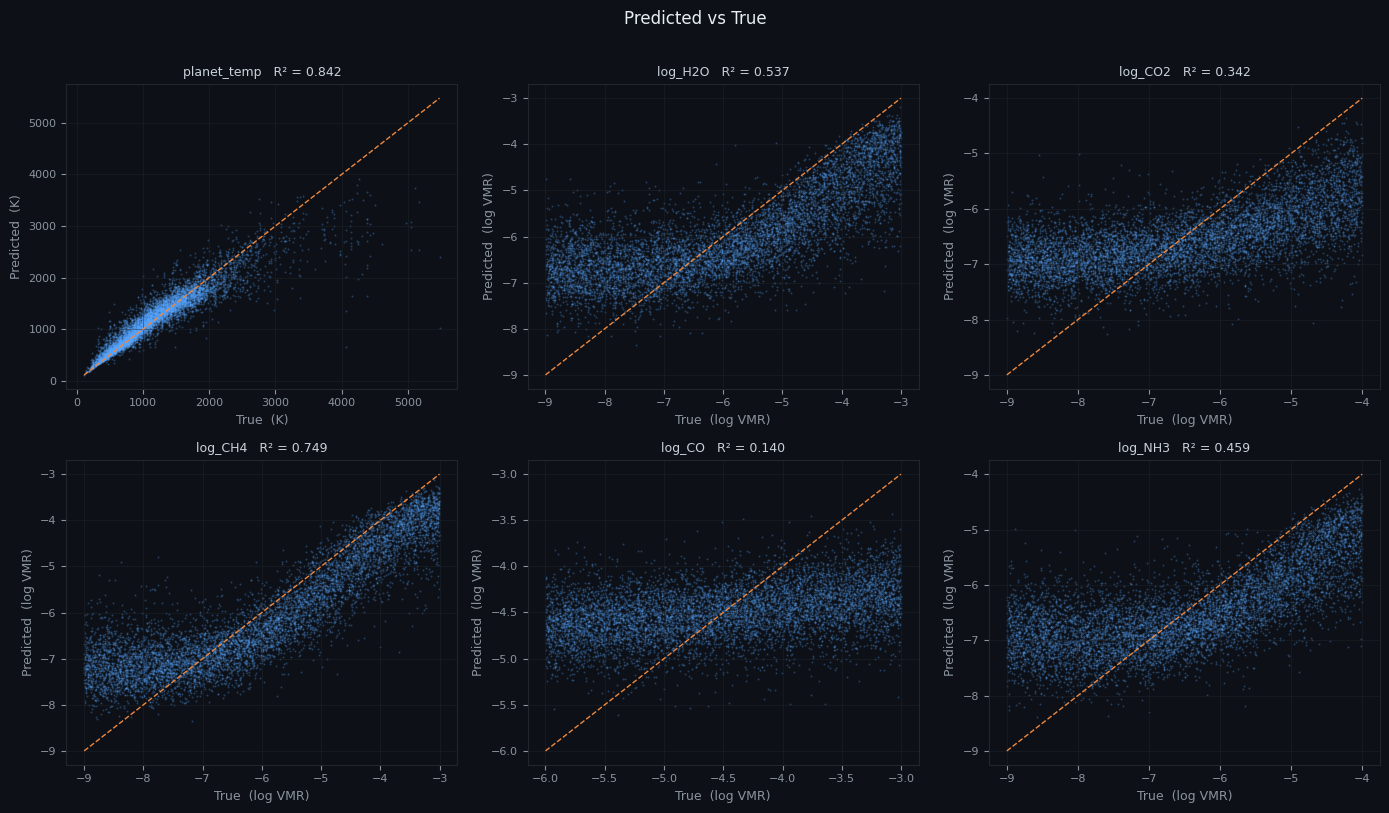

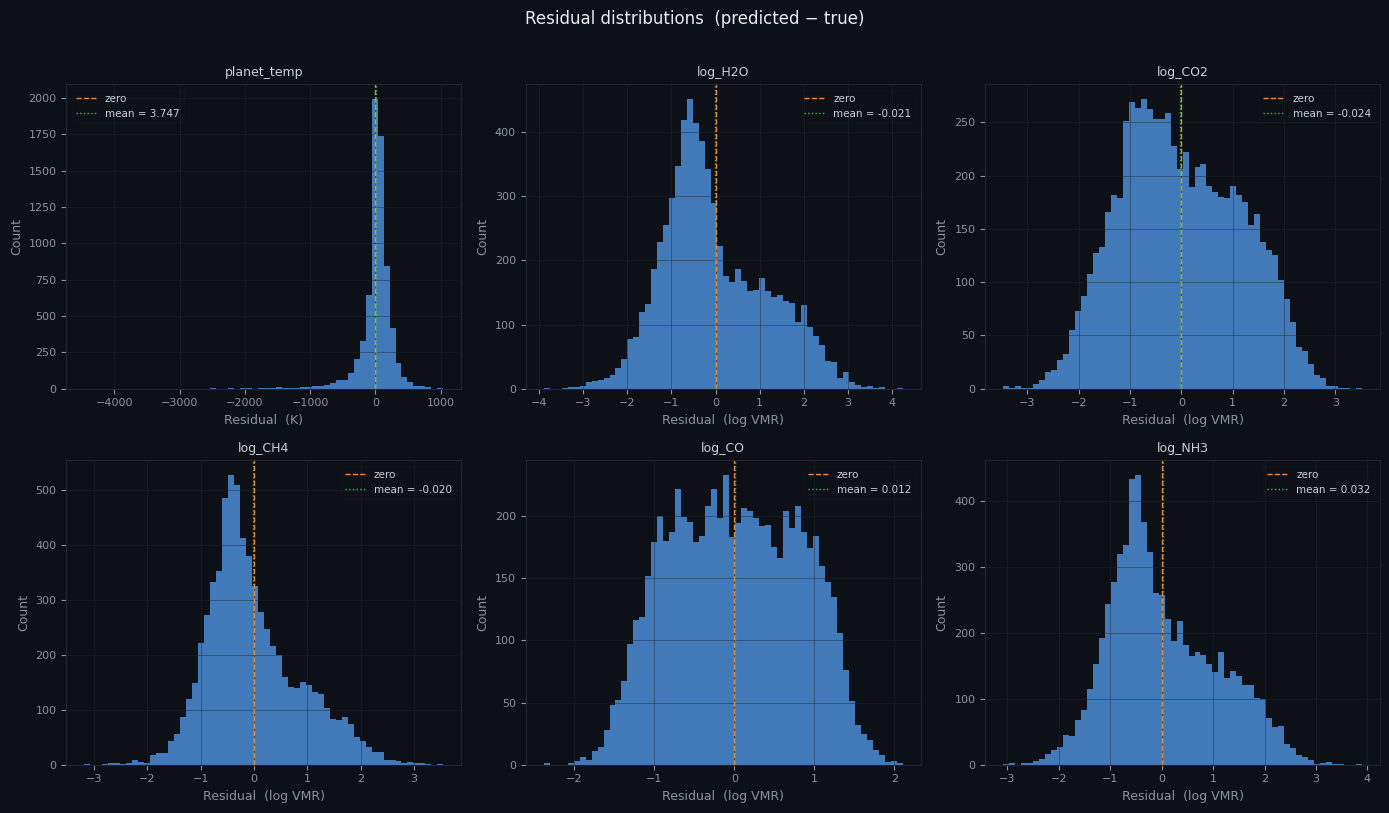

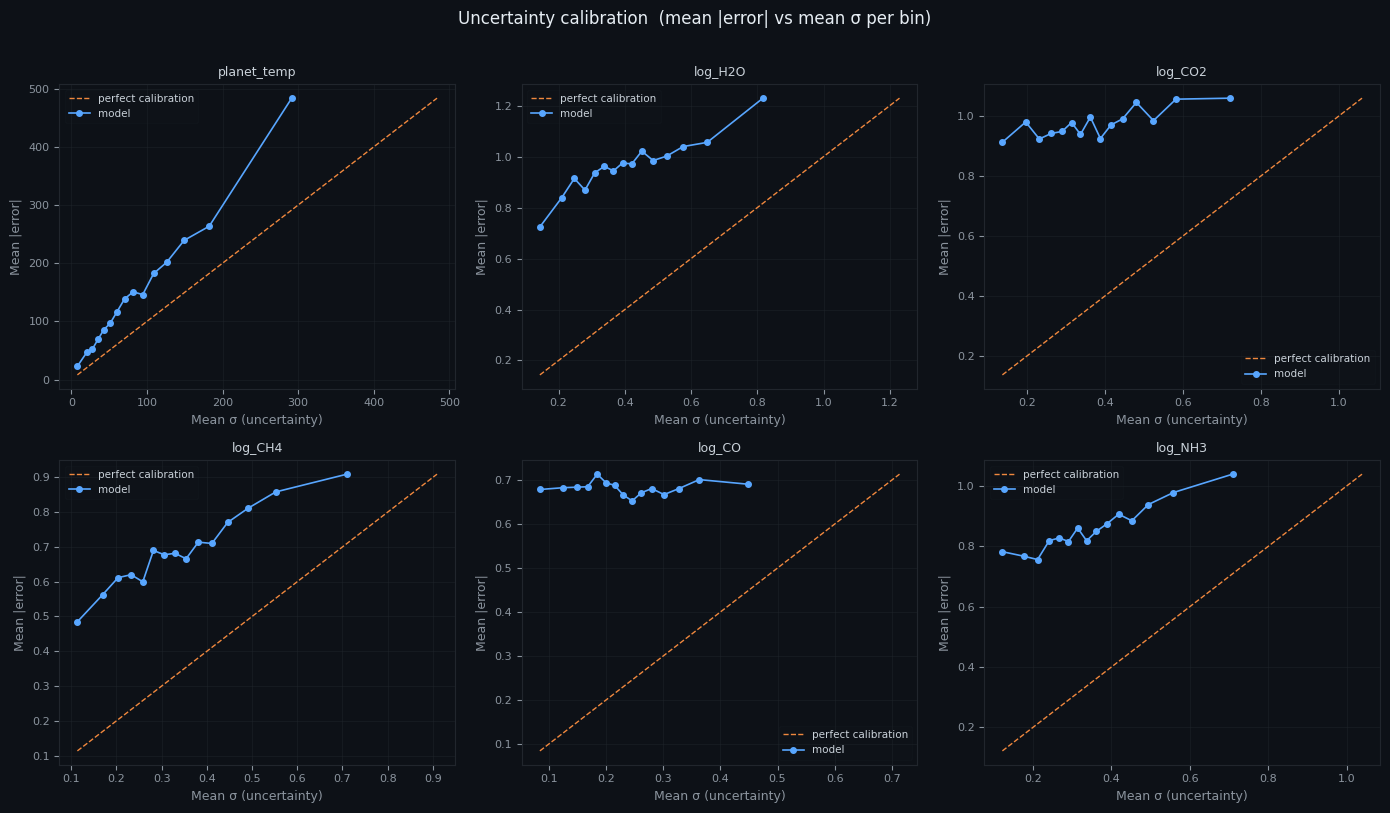

In [11]:
plot_predicted_vs_true(y_test, y_pred_mean)
plot_residuals(y_test, y_pred_mean)
plot_calibration(y_test, y_pred_mean, y_pred_std)

## Preparing the Submission

The leaderboard expects predictions in a specific tabular format: one row per planet, with columns for the planet ID followed by the six atmospheric targets. The `array_to_submission` helper handles this conversion from raw numpy arrays.

We produce three submission-formatted DataFrames:

- **`y_test_sub`** — the ground-truth values for the test set. This is useful as a reference and for local scoring before you submit. (you dont need that for submitting to leaderboard, oh well, you dont have it anyway!
- **`y_pred_mean_sub`** — your model's point predictions, one value per target per planet.
- **`y_pred_std_sub`** — your uncertainty estimates, one value per target per planet.

Both `y_pred_mean_sub` and `y_pred_std_sub` are required for a valid submission. A prediction without an accompanying uncertainty estimate is incomplete — the scoring metric penalises not only inaccurate predictions but also poorly calibrated confidence.

In [12]:
y_test_sub = array_to_submission(y_test,planet_ids=np.arange(0, len(y_test)))
y_pred_mean_sub = array_to_submission(y_pred_mean,planet_ids=np.arange(0, len(y_test)))
y_pred_std_sub = array_to_submission(y_pred_std,planet_ids=np.arange(0, len(y_test)))

In [13]:
# you can also calculate the score locally:
compute_participant_score(y_test_sub, y_pred_mean_sub, y_pred_std_sub)


{'score': 0.23792230326844596,
 'mean_crps': 0.44161903699841504,
 'crps_per_param': array([0.17433714, 0.45120388, 0.55804448, 0.31457631, 0.66348048,
        0.48807193]),
 'score_per_param': array([ 0.67368405,  0.22930475,  0.0369831 ,  0.46180031, -0.13152086,
         0.15728247])}

## Understanding the Score
### Score

![score concept](img/score_concept.svg)

Rather than reporting raw CRPS, the leaderboard uses a score that measures 
improvement over a trivial baseline — a model that predicts the training mean with 
training standard deviation for every planet:

$$\text{score} = 1 - \frac{\text{CRPS}_\text{model}}{\text{CRPS}_\text{baseline}}$$

The scoring function returns a dictionary with the following entries:

- **`score`** — the headline leaderboard value. A score of 1.0 is perfect; 0.0 means 
  your model performs no better than the trivial baseline; negative values indicate 
  it performs worse.

- **`mean_crps`** — the raw CRPS averaged across all planets and all six targets. 
  Lower is better in this case

- **`crps_per_param`** — mean CRPS per target, as an array of length 6 (ordered: 
  `planet_temp`, `log_H2O`, `log_CO2`, `log_CH4`, `log_CO`, `log_NH3`). Use this 
  to diagnose which targets your model struggles with most.

- **`score_per_param`** — the skill score broken down per target, also length 6. 
  Directly comparable across targets and models. A value near zero for a given 
  species indicates the model is not outperforming the baseline for that quantity — 
  a clear signal of where to direct further effort.


### Extra: what is CRPS?
The scoring function is based on the **Continuous Ranked Probability Score (CRPS)**, 
a metric designed for probabilistic predictions. Unlike a standard error metric, CRPS 
evaluates both the accuracy of your mean prediction and the honesty of your uncertainty 
estimate — a confident prediction that is wrong is penalised more harshly than an 
uncertain one. Lower CRPS is better but in our hackathon, the scoring is adjusted so that **higher is better!**. 

# Predicting on the Leaderboard Test Set

So far, all evaluation has been performed on a held-out portion of the training data — a split you created yourself with known ground truth. To generate a leaderboard score, you must now run inference on the official test set, for which **no** ground-truth labels are provided.

The test set follows the same structure as the training data: spectral observations and supplementary planetary parameters, without target values. We load the test spectra, pass them through each model in the ensemble, and aggregate the predictions in the same way as before — mean across folds for the point estimate, standard deviation across folds for the uncertainty.

These are the predictions you will submit.

##  Load the test data

In [14]:
lb_supp_data_path = os.path.join(data_dir, 'Test_supplementary_data.csv')
lb_spectral_data_path = os.path.join(data_dir, 'Test_SpectralData.hdf5')

lb_spectrum_stack, lb_noise_stack, wl_grid, width = load_spectral_data(lb_spectral_data_path)
predictions = np.array([m.predict(lb_spectrum_stack) for m in models])  # (n_folds, n_planets, n_targets)

lb_y_pred_mean = predictions.mean(axis=0)   # (n_planets, n_targets)
lb_y_pred_std  = predictions.std(axis=0)    # (n_planets, n_targets) — our uncertainty estimate

In [15]:
## to submission format
lb_y_pred_mean_sub = array_to_submission(lb_y_pred_mean,planet_ids=np.arange(0, len(lb_y_pred_mean)))
lb_y_pred_mean_sub = array_to_submission(lb_y_pred_std,planet_ids=np.arange(0, len(lb_y_pred_mean)))

## Submitting the solution to the leaderboard via API

## What Comes Next

This notebook has walked you through the full pipeline once: loading and understanding the data, training a baseline model, evaluating its performance, and submitting predictions to the leaderboard. That is the end of the guided portion — what follows is yours to explore.

The diagram above captures the intended workflow for the rest of the hackathon. The key insight is that steps 2 through 5 form a loop. Each leaderboard submission gives you a score on the official test set; that score, combined with your local evaluation, tells you where to direct your next effort. The teams that perform best are rarely those with the cleverest first idea — they are the ones who iterate most deliberately.

Some directions worth considering as you move into that loop:

- **Model architecture.** The baseline uses an ensemble of the same extra tree models, which are likely to produce the same predictions. Neural networks, gradient boosting methods, or Gaussian processes may offer different trade-offs between accuracy and uncertainty quality.
- **Input features.** So far, the raw spectrum is the only input. The supplementary data — stellar parameters, planetary radius, orbital properties — carries additional information that the model has not yet seen.
- **Uncertainty quality.** Ensemble standard deviation is a reasonable starting point, but it is not the only approach. Consider whether your uncertainty estimates are well-calibrated across the full range of targets, and whether some targets are harder to be confident about than others. There are other approaches that could outperform this. With a neural net, you can also train it direct to optimise the gaussian log likelihood.
- **Target-specific strategies.** The six targets are not equally difficult to predict, nor are they independent. It may be worth treating them differently, or exploiting correlations between them.


![title](img/hackathon_workflow.png)

## Tips about approaching the hackathon

**Plan before you build.**
Invest the opening portion of the session mapping out two or three distinct directions your team could pursue. Committing prematurely to a single approach is one of the most common failure modes in a time-limited setting.

**Divide work according to strength.**
Consider who in your team is most comfortable with data analysis, model development, and evaluation respectively. A well-divided team will cover more ground than one bottlenecked on a single thread.

**Explore in parallel.**
Progress is possible along multiple axes: data preprocessing, model architecture, uncertainty quantification, feature engineering, and ensemble strategies. Running these in parallel makes better use of limited time than pursuing them sequentially.

**Submit early and iterate.**
There is no penalty for multiple submissions. Establishing a baseline on the leaderboard early gives you a concrete reference point from which to measure improvement. A working solution submitted on time is worth more than an ambitious one that is not.